---
title: "Lab 3: Multiple Regression and Model Diagnostics (Python)"
format: html
jupyter: python3
---

## Overview

This lab mirrors the SPSS multiple-regression workflow from `jnb/workshop-4.html`, but in Python.

Assumption for this lab: data preparation was already completed in earlier labs, so required variables already exist.

### Dataset notes

- **cod** = Communicative Organizations Dataset (about 8,000 employees)
- **`info_*` variables** = Likert items where:
  - `1` = completely disagree
  - `5` = completely agree
  - focus = perceived access to information in organizational workplace contexts

### Key terms

- **Index variable**: combined score from multiple related items (here: `infoaccess_index`)
- **ANOVA F-test**: overall test of whether the regression model explains non-zero variance
- **Residual**: observed minus predicted value
- **t-test**: coefficient test (in regression output) for whether a predictor effect is different from zero
- **Pairwise exclusion**: each pairwise calculation uses all available cases for that pair of variables

## 1) Model specification

### Step 1: Load data and keep required variables

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12})

path = Path("cod-260210.tsv")
path = "https://github.com/cca-cce/osm-comm/raw/refs/heads/main/csv/cod-260210.tsv"
df = pd.read_csv(path, sep="\t")
print("shape:", df.shape)

# get dataset structure
df.info()

shape: (8091, 66)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8091 entries, 0 to 8090
Data columns (total 66 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID                                8091 non-null   int64  
 1   Gender                            6460 non-null   object 
 2   Age                               6407 non-null   float64
 3   Org_type                          8091 non-null   object 
 4   Role                              8087 non-null   object 
 5   info_work                         7945 non-null   float64
 6   info_org                          7781 non-null   float64
 7   info_vision                       7806 non-null   float64
 8   info_change                       7775 non-null   float64
 9   info_intracomm                    6998 non-null   float64
 10  info_mgmttrust                    7269 non-null   float64
 11  info_mgmttocow                    5717 non-null   f

### Step 2: Apply missing-data handling for the regression model

To match the simplified SPSS-style workflow, we use **listwise deletion for model variables**:

In [12]:
df_clean = df[cols].dropna().copy()
print("rows used in regression:", len(df_clean))
print(df_clean[cols].head())

rows used in regression: 4991
   infoaccess_index  age_years  dummy_gender Org_type  dummy_manager  \
1              12.0       35.0           0.0  Private            0.0   
2              19.0       49.0           1.0  Private            1.0   
3              28.0       60.0           1.0  Private            0.0   
4              24.0       31.0           1.0  Private            0.0   
5              25.0       52.0           1.0  Private            0.0   

   dummy_communicator  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  
5                 0.0  


### Step 3: Fit multiple regression model with `statsmodels`

`C(Org_type)` tells statsmodels to treat `Org_type` as categorical.

In [13]:
formula = (
    "infoaccess_index ~ age_years + dummy_gender + "
    "C(Org_type) + dummy_manager + dummy_communicator"
)

model = smf.ols(formula=formula, data=df_clean).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       infoaccess_index   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     28.29
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.23e-28
Time:                        12:33:55   Log-Likelihood:                -14652.
No. Observations:                4991   AIC:                         2.932e+04
Df Residuals:                    4985   BIC:                         2.936e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                20.68

### Step 4: Read core outputs in a compact table

In [14]:
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "t": model.tvalues,
    "p_value": model.pvalues,
    "ci_low_95": model.conf_int()[0],
    "ci_high_95": model.conf_int()[1],
})
print(coef_table.round(4))
print(f"\nR-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"Model F-test p-value: {model.f_pvalue:.3g}")

                          coef  std_err        t  p_value  ci_low_95  \
Intercept              20.6894   0.3229  64.0643   0.0000    20.0563   
C(Org_type)[T.Public]  -0.0207   0.1565  -0.1320   0.8950    -0.3274   
age_years               0.0253   0.0062   4.0852   0.0000     0.0131   
dummy_gender            0.7658   0.1437   5.3281   0.0000     0.4840   
dummy_manager           1.5114   0.1581   9.5593   0.0000     1.2015   
dummy_communicator      0.0963   0.2409   0.3997   0.6894    -0.3760   

                       ci_high_95  
Intercept                 21.3225  
C(Org_type)[T.Public]      0.2861  
age_years                  0.0374  
dummy_gender               1.0475  
dummy_manager              1.8214  
dummy_communicator         0.5686  

R-squared: 0.0276
Adjusted R-squared: 0.0266
Model F-test p-value: 2.23e-28


## 2) Model diagnostics

### Step 1: Check predictor correlations (pairwise complete)

This mirrors SPSS **exclude cases pairwise** behavior for the correlation matrix.

                    age_years  dummy_gender  dummy_manager  dummy_communicator
age_years               1.000         0.005          0.092              -0.097
dummy_gender            0.005         1.000         -0.101               0.031
dummy_manager           0.092        -0.101          1.000              -0.123
dummy_communicator     -0.097         0.031         -0.123               1.000


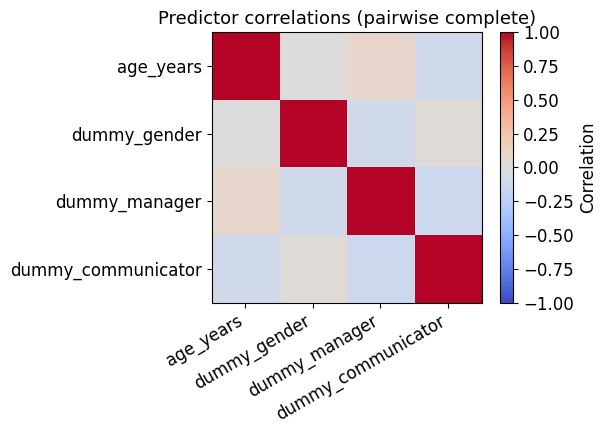

In [15]:
pred_cols = ["age_years", "dummy_gender", "dummy_manager", "dummy_communicator"]
corr_pw = df[pred_cols].corr()  # pairwise complete by default
print(corr_pw.round(3))

plt.figure(figsize=(6, 4.5))
plt.imshow(corr_pw.values, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(pred_cols)), pred_cols, rotation=30, ha="right")
plt.yticks(range(len(pred_cols)), pred_cols)
plt.title("Predictor correlations (pairwise complete)")
plt.tight_layout()

### Step 2: Check multicollinearity with VIF

In [16]:
# Build design matrix from the fitted model data (without intercept in formula terms)
X_vif = pd.get_dummies(
    df_clean[["age_years", "dummy_gender", "Org_type", "dummy_manager", "dummy_communicator"]],
    drop_first=True
).astype(float)
X_vif = sm.add_constant(X_vif, has_constant="add")

vif_rows = []
for i, col in enumerate(X_vif.columns):
    if col == "const":
        continue
    vif_rows.append((col, variance_inflation_factor(X_vif.values, i)))

vif_df = pd.DataFrame(vif_rows, columns=["predictor", "VIF"])
print(vif_df.round(3))

            predictor    VIF
0           age_years  1.021
1        dummy_gender  1.143
2       dummy_manager  1.042
3  dummy_communicator  1.039
4     Org_type_Public  1.141


### Step 3: Residuals vs fitted values

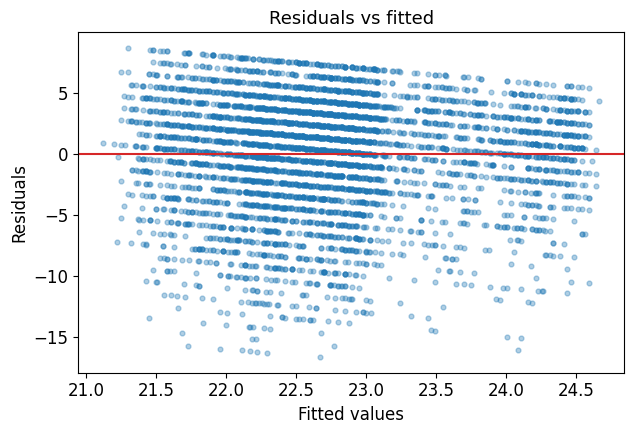

In [17]:
fitted = model.fittedvalues
resid = model.resid

plt.figure(figsize=(6.5, 4.5))
plt.scatter(fitted, resid, alpha=0.35, s=12)
plt.axhline(0, color="tab:red", linewidth=1.5)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs fitted")
plt.tight_layout()

### Step 4: Normal Q-Q plot of residuals

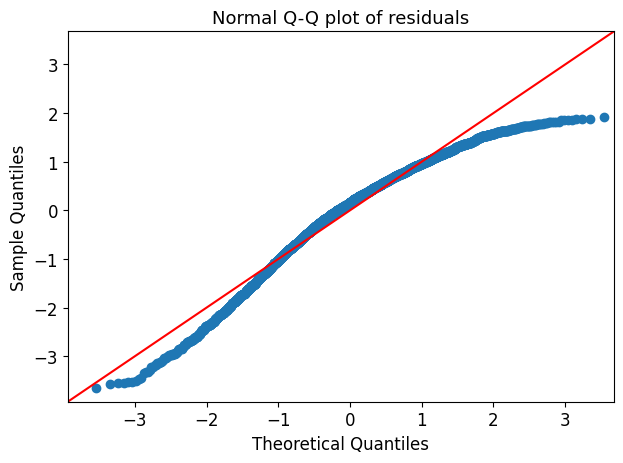

In [18]:
fig = sm.qqplot(model.resid, line="45", fit=True)
plt.title("Normal Q-Q plot of residuals")
plt.tight_layout()

### Step 5: Casewise diagnostics (large standardized residuals)

In [19]:
influence = model.get_influence()
std_resid = influence.resid_studentized_internal

flag = np.abs(std_resid) > 3
print("Potential outliers (|standardized residual| > 3):", int(flag.sum()))

if flag.sum() > 0:
    out = df_clean.loc[flag, cols].copy()
    out["std_resid"] = std_resid[flag]
    print(out.head(10))

Potential outliers (|standardized residual| > 3): 27
      infoaccess_index  age_years  dummy_gender Org_type  dummy_manager  \
659                9.0       57.0           1.0   Public            0.0   
671                8.0       45.0           1.0   Public            1.0   
754                9.0       46.0           1.0   Public            1.0   
773                6.0       57.0           0.0   Public            0.0   
1661               9.0       52.0           0.0   Public            1.0   
1817               8.0       33.0           1.0   Public            0.0   
1944               8.0       30.0           1.0   Public            0.0   
2056               6.0       51.0           0.0   Public            0.0   
2077               7.0       61.0           0.0   Public            0.0   
2832               6.0       38.0           0.0   Public            0.0   

      dummy_communicator  std_resid  
659                  0.0  -3.043606  
671                  0.0  -3.528971  
754    

## Wrap-up

This notebook now follows one clear workflow:
- specify model
- fit with `statsmodels` formula OLS
- inspect coefficients and model fit
- run core diagnostics (pairwise correlations, VIF, residual plots, casewise checks)

For Quarto conversion:
- `quarto convert jnb/lab3.qmd --to ipynb`